In [16]:
using LowLevelFEM, LinearAlgebra

# Strain-to-displacement reconstruction

This example reconstructs a displacement field from a prescribed strain field.

Instead of solving an equilibrium problem, the kinematic relation

$$
\boldsymbol{\varepsilon}
=
\frac12
\left(
\nabla\mathbf{u}
+
(\nabla\mathbf{u})^T
\right)
$$

is inverted in its weak form. Such problems arise, for example, in digital image correlation (DIC), experimental mechanics, or whenever a compatible displacement field is sought from measured strain data.

## Mesh and finite element model

A simple cantilever beam is created using quadratic hexahedral elements.

The whole boundary is assigned to the physical group `"free"`. Later, only a few displacement constraints are introduced to eliminate rigid body modes.

In [17]:
structured_box_mesh(y0=-0.5, lx=10, n=4, order=2)

In [18]:
gmsh.model.addPhysicalGroup(2, [1, 2, 3, 4, 5, 6], -1, "free")

gmsh.model.addPhysicalGroup(0, [1], -1, "1")
gmsh.model.addPhysicalGroup(0, [2], -1, "2")
gmsh.model.addPhysicalGroup(0, [3], -1, "3")

11

## Prescribed strain field

A compatible analytical strain field is defined.

The strain corresponds to pure bending of a cantilever beam,

$$
\varepsilon_{xx}=\frac{y}{100},
$$

while the remaining normal strains follow from Poisson's ratio,

$$
\varepsilon_{yy}
=
\varepsilon_{zz}
=
-\nu\varepsilon_{xx}.
$$

Since the strain field is analytically compatible, the reconstructed displacement should reproduce it with high accuracy.

In [19]:
mat = Material("body")
Pu = Problem([mat], type=:VectorField, field=:u, rhs_field=:f);

In [20]:
ν = mat.ν
ex(x, y, z) = y / 100
eyz(x, y, z) = -ν * ex(x, y, z)
ε = TensorField(Pu, "body", [ex 0 0; 0 eyz 0; 0 0 eyz]);

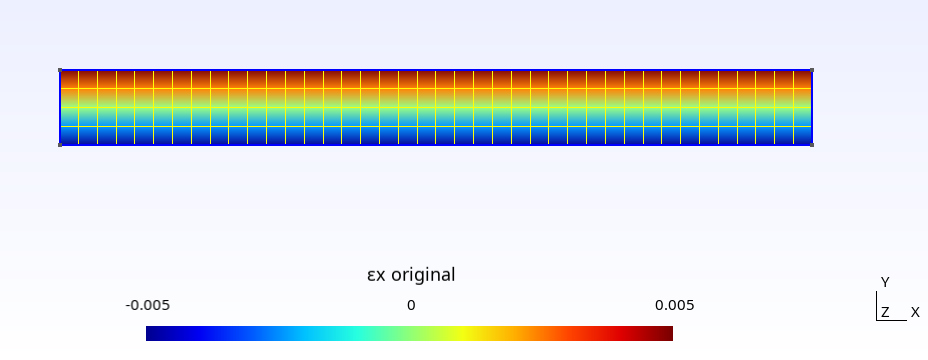

## Weak formulation

The displacement field is obtained from the weak form

$$
\int_\Omega
\boldsymbol{\varepsilon}(\mathbf{v})
:
\boldsymbol{\varepsilon}(\mathbf{u})
\,d\Omega
=
\int_\Omega
\boldsymbol{\varepsilon}(\mathbf{v})
:
\boldsymbol{\varepsilon}^{*}
\,d\Omega ,
$$

where $\boldsymbol{\varepsilon}^{*}$ denotes the prescribed strain field.

In LowLevelFEM this can be assembled directly using the operator notation.

Since `SymGrad` stores the engineering shear strains, the matrix

$$
W=\mathrm{diag}(1,1,1,\tfrac12,\tfrac12,\tfrac12)
$$

converts the engineering representation into the standard tensor inner product.

In [21]:
W = diagm([2., 2, 2, 1, 1, 1]) / 2

6×6 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.5  0.0  0.0
 0.0  0.0  0.0  0.0  0.5  0.0
 0.0  0.0  0.0  0.0  0.0  0.5

In [22]:
K = ∫(SymGrad(Pu) ⋅ W ⋅ SymGrad(Pu))
K[:, :]

19683×19683 SparseArrays.SparseMatrixCSC{Float64, Int64} with 3139109 stored entries:
⎡⣿⣿⣻⣿⠶⣶⣇⣃⣀⣸⡿⢟⣘⡿⣼⠛⢻⣻⡟⠶⠇⢘⣀⣘⣛⠀⠃⠈⠀⠚⠯⣤⡇⠘⠀⠃⠧⡇⠃⠛⎤
⎢⣿⣾⢿⣷⡤⣄⡏⠏⠉⢻⣷⡒⠙⣿⣴⠿⣷⣷⣿⣄⡂⠰⠀⠹⢿⣄⡆⠰⠀⠶⣶⣄⡆⠸⠉⠏⣧⡆⠏⠿⎥
⎢⢸⣧⠀⢯⠻⣦⡀⠀⠀⢸⢸⡀⠀⡟⡇⠀⢻⣿⡜⢧⠀⠀⠀⠀⠘⢦⠀⠀⠀⠀⠘⣦⠀⠀⠀⠀⠹⡄⠀⠀⎥
⎢⠭⢹⡯⠍⠀⠈⢿⣷⡒⠮⡇⠹⣾⢿⠉⡿⣿⢿⡷⠈⠁⠸⡗⢾⠦⠈⠁⠸⡗⢾⠆⠈⠁⢸⡖⢿⠆⠁⣗⡷⎥
⎢⣀⣸⣧⣀⣀⣀⡸⡌⠻⣦⣇⣀⢿⣼⠀⢹⣏⣿⢧⣀⣀⣀⠙⣎⣇⠀⠀⠀⠹⣞⡇⠀⠀⠀⠹⡞⡆⠀⠸⣽⎥
⎢⣿⢏⢹⠻⠒⠲⣍⡉⠉⢹⣿⣿⣍⠁⠀⠀⢿⡅⠸⣿⣿⣯⣭⣉⠉⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⣶⡼⣷⣤⣤⠤⣾⣟⣛⣷⠇⠙⠿⣧⣤⣤⡘⢧⣄⠀⠉⠙⠛⠿⠷⠀⠀⠀⠀⠀⣤⢤⣤⣤⣤⣀⣤⣤⣤⣀⎥
⎢⣶⠛⣴⡟⠉⠉⣧⡤⣄⣀⠀⠀⠀⣿⢿⣷⡄⠸⣧⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠚⠻⢿⣿⣶⣤⡚⢿⣷⣄⎥
⎢⣿⣲⢽⣿⣿⣶⣿⣟⣯⣽⠟⠷⠶⣌⣀⡉⢿⣷⣽⣷⣿⣶⣶⣶⣼⣶⣿⣶⣶⣶⣤⣤⣤⣬⣭⣉⣁⣀⠉⠉⎥
⎢⢻⡍⠛⢿⠶⣍⡙⠋⠉⢳⣶⣦⠀⠙⠉⠛⢷⣿⠻⣦⡲⣄⠀⠀⠸⣯⡻⣟⠉⠛⠋⠉⠉⠛⠙⠋⠋⠉⠛⠛⎥
⎢⣉⢁⢈⡈⠀⠀⣁⡀⠀⢸⡿⣿⣇⠀⠀⠀⢻⣿⠘⢮⡻⣮⡳⣄⠘⢮⡻⣮⡳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⣀⢸⣄⡀⠀⠀⣹⣍⡳⢤⡇⢻⣿⡄⠀⠀⢸⣿⠀⠀⠙⢮⣻⣾⣆⠀⠙⢮⣻⣞⡆⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠛⠘⠛⢷⠲⣄⡈⠃⠉⠙⠃⠀⠙⠃⠀⠀⢲⣿⡶⣦⡲⣄⠈⠙⠻⣦⡲⣄⠈⠛⠳⣦⡲⣄⠀⠀⠀⠀⠀⠀⎥
⎢⡉⠀⢈⡉⠀⠀⣁⡀⠀⠀⠀⠀⠀⠀⠀⠀⢻⣿⣿⢮⡻⣮⡳⣄⠘⢮⡻⣮⡳⣄⠙⢮⡻⣮⡳⣄⠀⠀⠀⠀⎥
⎢⣠⠀⢠⡄⠀⠀⣹⣍⣳⢦⠀⠀⠀⠀⠀⠀⢸⣿⣧⠀⠙⢮⣻⢾⣦⠀⠙⢮⣻⣾⡆⠀⠙⢮⣻⣞⠆⠀⠀⠀⎥
⎢⠋⣧⠘⢿⠲⣤⡈⠁⠉⠉⠀⠀⠀⣟⣾⡀⠀⣿⡏⠀⠀⠀⠈⠉⠹⣦⡳⣄⠈⠉⠻⣦⡳⣄⠈⠉⢳⣷⡀⠀⎥
⎢⣉⠉⣈⡉⠀⠀⣁⣀⠀⠀⠀⠀⠀⣿⣿⣷⡀⣿⣧⠀⠀⠀⠀⠀⠘⢮⡻⣮⡳⣄⠙⢮⡻⣮⡳⣄⠹⣽⡽⡄⎥
⎢⠤⠀⡧⠄⠀⠀⣼⣍⣳⠦⠀⠀⠀⢻⠘⣿⡇⢻⡷⠀⠀⠀⠀⠀⠀⠀⠙⢮⣻⢾⡆⠀⠙⢮⣻⣾⡆⠙⣿⣷⎥
⎢⠭⠧⠩⠿⠓⠦⠌⠁⠈⠉⠀⠀⠀⣿⣾⣌⠁⢸⡏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠁⢽⣶⣗⣦⣌⠉⢿⣷⣌⠉⎥
⎣⣭⠀⣯⡅⠀⠀⢽⡽⣖⣦⠀⠀⠀⢻⠙⢿⡇⠀⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠓⠯⢿⣿⡆⠙⢿⣷⎦

In [23]:
f = ∫(SymGrad(Pu) ⋅ W ⋅ [ε[1, 1], ε[2, 2], ε[3, 3], ε[1, 2], ε[2, 3], ε[3, 1]]);

Only a minimal set of displacement constraints is prescribed.

These constraints do not represent physical supports; they merely eliminate the rigid body modes, making the linear system uniquely solvable.

In [24]:
supp1 = BoundaryCondition("1", ux=0, uy=0, uz=0)
supp2 = BoundaryCondition("2", ux=0, uy=0);
supp3 = BoundaryCondition("3", ux=0);

In [25]:
u = solveField(K, f, support=[supp1, supp2, supp3]);   # rigid mode kizárás

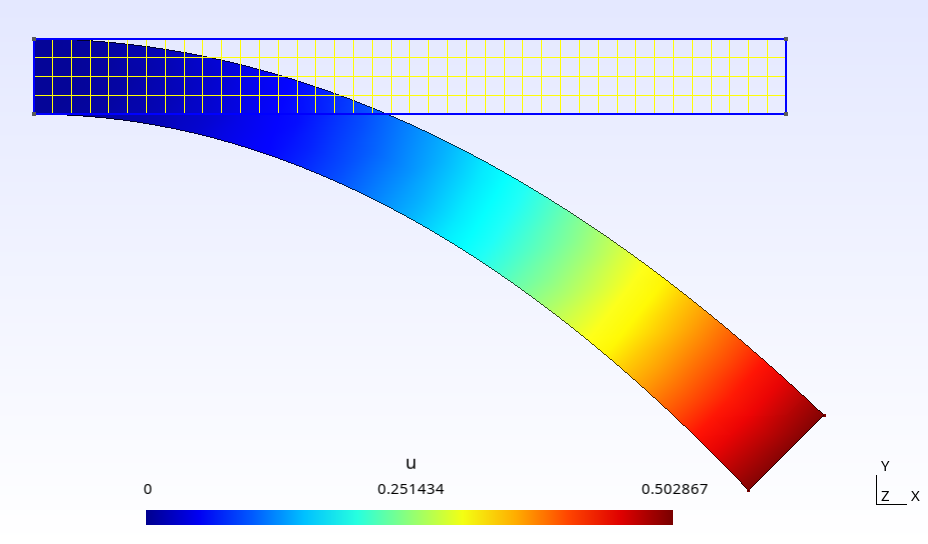

In [26]:
showDoFResults(u, name="u", visible=true, factor=10);

In [27]:
showDoFResults(ε, :x, name="εx original");

## Verification

The reconstructed displacement field is differentiated again to obtain the strain field

$$
\boldsymbol{\varepsilon}_{\mathrm{rec}}
=
\frac12
\left(
\nabla\mathbf{u}
+
(\nabla\mathbf{u})^T
\right).
$$

Finally, the reconstructed strain is compared with the prescribed one.

For this compatible analytical example, the difference is close to machine precision over most of the domain.

In [28]:
ε_rec = (u ∘ ∇ + ∇ ∘ u) / 2
showDoFResults(ε_rec, :x, name="εx reconstructed");

In [29]:
showDoFResults(ε - ε_rec, name="strain error");

This example illustrates that LowLevelFEM can be used not only for classical equilibrium problems, but also for solving inverse problems formulated directly from differential operators and their weak forms.

In [30]:
openPostProcessor()